# Duration Times Spread Strategies

In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
note_path = os.getcwd()
repo_path = os.path.abspath(os.path.join(note_path, ".."))
data_path = os.path.join(repo_path, "data")

In [3]:
ticker_path   = os.path.join(data_path, "CreditTickers.xlsx")
plot_renamer_ = (pd
    .read_excel(io = ticker_path)
    .assign(ticker = lambda x: x.ticker.str.split(" ").str[0])
    .set_index("ticker")
    .plot_name
    .to_dict())

renamer = {**plot_renamer_}

# Strategy 1: High Yield Risk Premia Compensation

High yield securities are quoted in prices as opposed to the investment grade bonds which are quoted in OAS because high yield securities tend to have are more equity-like component. *Duration-time-spread* (DTS) offers are new risk measurement for credit modelling that is universal across bond ratings, and has a much better accuracy in modelling risk. Therefore we can develop a strategy that profits on getting componesated for DTS. The idea is that we can measure spread risk in terms of OAS and bond risk in terms of DTS. Z-scoring these risk measures and taking their difference yield us an indicator for getting compensated for the risk. For example OAS may widen implying more risk but if DTS doesn't widen as much then we can deploy capital getting compensated for that risk and vice versa.

In [12]:
tickers = ['I00185US','I09036US','LF98TRUU','LHVLTRUU']

In [13]:
path   = os.path.join(data_path, "SlicedCreditData.parquet")
df_raw = (pd
    .read_parquet(path = path, engine = "pyarrow")
    .assign(security = lambda x: x.security.str.split(" ").str[0])
    .loc[lambda x: x.security.isin(tickers)])

In [14]:
start_date = (df_raw
    .pivot(index = "date", columns = "security", values = "oas")
    .reset_index()
    [["date"]]
    .assign(
        lag_date    = lambda x: x.date.shift(),
        spread_date = lambda x: (x.date - x.lag_date).dt.days)
    .loc[lambda x: x.spread_date <= 4]
    .date
    .iloc[0])

In [15]:
df_sliced = (df_raw
    .loc[lambda x: x.date >= start_date])

In [16]:
window = 100

df_signal = (df_sliced
    [["date", "security", "oas", "sprd_dur"]]
    .set_index("date")
    .assign(dur_oas = lambda x: x.sprd_dur * x.oas)
    .drop(columns = ["sprd_dur"])
    .groupby("security")
    .apply(lambda x: (x - x.ewm(span = window, adjust = False).mean()) / x.ewm(span = window, adjust = False).std())
    .assign(signal = lambda x: x.oas - x.dur_oas)
    .reset_index()
    .pivot(index = "date", columns = "security", values = "signal")
    .shift()
    .reset_index()
    .melt(id_vars = "date", value_name = "lag_signal")
    .dropna())

In [17]:
df_signal_rtn = (df_sliced
    .pivot(index = "date", columns = "security", values = "truu")
    .pct_change()
    .reset_index()
    .melt(id_vars = "date", value_name = "px_rtn")
    .merge(right = df_signal, how = "inner", on = ["date", "security"])
    .assign(signal_rtn = lambda x: np.sign(x.lag_signal) * x.px_rtn))

In [18]:
df_vol_rtn = (df_signal_rtn
    .pivot(index = "date", columns = "security", values = "signal_rtn")
    .apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252))))
    .reset_index()
    .melt(id_vars = "date", value_name = "vol_rtn")
    .dropna())

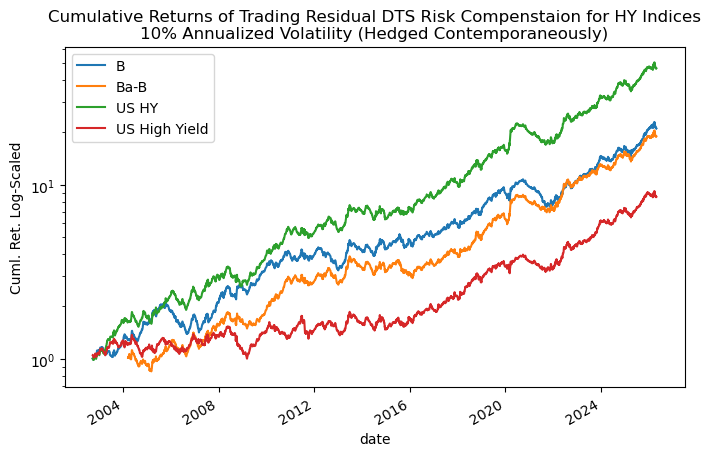

In [25]:
(df_vol_rtn
    .rename(columns = {"security": ""})
    .pivot(index = "date", columns = "", values = "vol_rtn")
    .apply(lambda x: np.cumprod(1 + x))
    .rename(columns = renamer)
    .plot(
        figsize = (8,5),
        logy    = True,
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = "Cumulative Returns of Trading Residual DTS Risk Compenstaion for HY Indices\n10% Annualized Volatility (Hedged Contemporaneously)"))

plt.show()

In [28]:
(df_vol_rtn
    .drop(columns = ["date"])
    .groupby("security")
    .agg(lambda x: x.mean() / x.std() * np.sqrt(252))
    .T
    .assign(Avg = lambda x: x.mean(axis = 1)))

security,I00185US,I09036US,LF98TRUU,LHVLTRUU,Avg
vol_rtn,1.377526,1.397451,1.722027,0.980945,1.369487
